# SVM - Kernels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [ ]:
x = np.linspace(-25.0, 25.0, 1000)
y = np.sqrt(25**2 - x**2)

In [ ]:
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [ ]:
plt.plot(x, y)
plt.axis("equal")
plt.show()


In [ ]:
x1 = np.linspace(-20.0, 20.0, 1000)
y1 = np.sqrt(20**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

In [ ]:
plt.plot(x1, y1)
plt.axis("equal")
plt.show()


In [ ]:
theta = np.linspace(0, 2*np.pi, 400)
a = 15 * np.cos(theta)
b = 15 * np.sin(theta)

plt.plot(a, b)
plt.axis("equal")
plt.show()


In [ ]:
plt.plot(x1, y1)
plt.plot(x, y)
plt.plot(a, b)
plt.axis("equal")
plt.show()

In [ ]:
y

In [ ]:
# lets make it like: x1,x2,x3 each with y=0,1,2 respectively
df1 = pd.DataFrame(np.vstack([y,x]).T,columns = ['X1','X2'])
df1['Y']=0
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns = ['X1','X2'])
df2['Y']=0
df3 = pd.DataFrame(np.vstack([b,a]).T,columns = ['X1','X2'])
df3['Y']=0
df = pd.concat([df1, df2, df3], ignore_index=True)

- *bad way as we have duplicate values due to using the 'hstack' function*

we know:
x=rcos(θ),y=rsin(θ)

for a circle so we will make a linearly seperable theta array and use that to get x and y

In [ ]:
n = 1000
theta = np.linspace(0,2*np.pi,n)

In [ ]:
r0 = 25 #radius
x0 = r0 * np.cos(theta)
y0 = r0 * np.sin(theta)
y0_lbl = np.zeros(n)


r1 = 20 #radius
x1 = r1 * np.cos(theta)
y1 = r1 * np.sin(theta)
y1_lbl = np.ones(n)


r2 = 15 #radius
x2 = r2 * np.cos(theta)
y2 = r2 * np.sin(theta)
y2_lbl = np.full(n, 2)

In [ ]:
X0 = np.column_stack((x0,y0))
X1 = np.column_stack((x1,y1))
X2 = np.column_stack((x2,y2))

In [ ]:
X = np.vstack((X0,X1,X2))
y = np.hstack((y0_lbl,y1_lbl,y2_lbl))

In [ ]:
X

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=5)
plt.axis("equal")
plt.show()


In [ ]:
df = pd.DataFrame(X,columns=['X1','X2'])
df

In [ ]:
df.tail()

In [ ]:
df['y']=y
df.head()

In [ ]:
df.tail()

In [ ]:
df.info()

In [ ]:
X = df.iloc[:,:2]
X

In [ ]:
y=df['y']
y

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    random_state=67,
    test_size=0.25,
)

In [ ]:
X_train

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = SVC(kernel='linear')  # linear SVM in your new 5D feature space
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
from sklearn.metrics import precision_score

precision_score(y_test, y_pred, average='macro', zero_division=0)


*We will be using different kernels and try to do it with and without scaling*

1. Polynomial Kernel


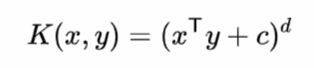

In [ ]:
df['X1_squared']=df['X1']**2
df['X2_squared']=df['X2']**2
df['X1*X2']=(df['X1']*df['X2'])
df.head()

In [ ]:
df.columns

In [ ]:
X = df[['X1', 'X2', 'X1_squared', 'X2_squared', 'X1*X2']]
X

In [ ]:
y=df['y']
y

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    random_state=67,
    test_size=0.25,
)

In [ ]:
X_train

In [ ]:
# %pip install -r C:\xtra\Last_Chance\git_re\inexorable-ML\requirements.txt

In [ ]:
# %pip install --upgrade nbformat ipython

In [ ]:
import plotly.express as px

fig = px.scatter_3d(df,x='X1',y='X2',z='X1*X2', color=y)
fig.show()


In [ ]:

fig = px.scatter_3d(df,x='X1_squared',y='X2_squared',z='X1*X2', color=y)
fig.show()

In [ ]:
X_train

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = SVC(kernel='linear')  # linear SVM in your new 5D feature space
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = SVC(kernel='poly')  # linear SVM in your new 5D feature space
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = SVC(kernel='rbf')  # linear SVM in your new 5D feature space
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = SVC(kernel='sigmoid')  # linear SVM in your new 5D feature space
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


*Learned Kernel functions and how transforming data significantly improves the accuracy and other metrics*